In [1]:
! pip install pandas numpy missingno seaborn scikit-learn

In [11]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn import datasets

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#pd.reset_option('display.max_rows')
#pd.reset_option('display.max_columns')

# first phase

In [57]:
filePath = 'combined.csv'
df = pd.read_csv(filePath)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,Attendance,HHW,AHW,HO,AO
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12926,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,...,2.26,1.74,2.29,1.68,2.22,NaN,NaN,NaN,NaN,NaN
12927,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,...,2.65,1.52,2.72,1.50,2.60,NaN,NaN,NaN,NaN,NaN
12928,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,...,2.23,1.74,2.28,1.68,2.21,NaN,NaN,NaN,NaN,NaN
12929,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,...,2.61,1.53,2.80,1.49,2.63,NaN,NaN,NaN,NaN,NaN


In [58]:
columnsToDrop = ['Time', 'Attendance', 'HHW', 'AHW', 'HO', 'AO']
df = df.drop(columns=columnsToDrop)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AvgA,MaxH,MaxD,MaxA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12926,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,...,6.58,1.53,5.0,7.25,1.68,2.26,1.74,2.29,1.68,2.22
12927,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,...,2.37,2.88,4.1,2.45,1.50,2.65,1.52,2.72,1.50,2.60
12928,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,...,3.65,2.00,4.2,3.82,1.69,2.23,1.74,2.28,1.68,2.21
12929,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,...,5.76,1.56,4.9,6.00,1.50,2.61,1.53,2.80,1.49,2.63


In [59]:
print(df['Date'].head(20))
print(df['Date'].tail(20))
print(df['Date'].unique()[:20])  # First 20 unique values

0     19/08/06
1     19/08/06
2     19/08/06
3     19/08/06
4     19/08/06
5     19/08/06
6     19/08/06
7     19/08/06
8     20/08/06
9     20/08/06
10    22/08/06
11    22/08/06
12    23/08/06
13    23/08/06
14    23/08/06
15    23/08/06
16    23/08/06
17    23/08/06
18    26/08/06
19    26/08/06
Name: Date, dtype: object
12911    20/05/2023
12912    20/05/2023
12913    20/05/2023
12914    20/05/2023
12915    21/05/2023
12916    21/05/2023
12917    21/05/2023
12918    22/05/2023
12919    24/05/2023
12920    25/05/2023
12921    28/05/2023
12922    28/05/2023
12923    28/05/2023
12924    28/05/2023
12925    28/05/2023
12926    28/05/2023
12927    28/05/2023
12928    28/05/2023
12929    28/05/2023
12930    28/05/2023
Name: Date, dtype: object
['19/08/06' '20/08/06' '22/08/06' '23/08/06' '26/08/06' '27/08/06'
 '28/08/06' '09/09/06' '10/09/06' '11/09/06' '16/09/06' '17/09/06'
 '20/09/06' '23/09/06' '24/09/06' '25/09/06' '30/09/06' '01/10/06'
 '02/10/06' '14/10/06']


In [63]:
def date_format_type(date_str):
    if not isinstance(date_str, str):
        return "not_a_string"
    patterns = {
        "%d/%m/%y": r"^\d{2}/\d{2}/\d{2}$",
        "%d/%m/%Y": r"^\d{2}/\d{2}/\d{4}$",
        "%Y-%m-%d": r"^\d{4}-\d{2}-\d{2}$",
        "%m-%d-%Y": r"^\d{2}-\d{2}-\d{4}$",
        "%Y/%m/%d": r"^\d{4}/\d{2}/\d{2}$",
    }
    for fmt, pat in patterns.items():
        if re.match(pat, date_str):
            return fmt
    return "unknown"

df['DateFormat'] = df['Date'].apply(date_format_type)
print(df['DateFormat'].value_counts())
print(df[df['DateFormat'] == "unknown"]['Date'].unique())
print(df[df['DateFormat'] == "not_a_string"]['Date'].unique())

DateFormat
%d/%m/%y        8434
%d/%m/%Y        3800
not_a_string     697
Name: count, dtype: int64
[]
[nan]


In [64]:
def parse_dates(row):
    date_str = row['Date']
    if isinstance(date_str, str):
        try:
            return pd.to_datetime(date_str, format='%d/%m/%y')
        except ValueError:
            try:
                return pd.to_datetime(date_str, format='%d/%m/%Y')
            except ValueError:
                return pd.NaT
    else:
        return pd.NaT

df['ParsedDate'] = df.apply(parse_dates, axis=1)
print("Unparsed dates after dual parsing:", df['ParsedDate'].isna().sum())

Unparsed dates after dual parsing: 697


In [68]:
def get_season(date):
    if pd.isnull(date):
        return np.nan
    year = date.year
    month = date.month
    if month >= 8: 
        return f"{year}-{str(year+1)[-2:]}"
    else:          
        return f"{year-1}-{str(year)[-2:]}"

df['Season'] = df['ParsedDate'].apply(get_season)
print(df['Season'].value_counts())

Season
1993-94    462
1994-95    462
2006-07    380
2011-12    380
2007-08    380
2008-09    380
2021-22    380
2016-17    380
2013-14    380
2020-21    380
1997-98    380
1998-99    380
2019-20    380
2014-15    380
2002-03    380
2015-16    380
1995-96    380
1999-00    380
2018-19    380
2017-18    380
2000-01    380
1996-97    380
2024-25    380
2012-13    380
2005-06    380
2001-02    380
2009-10    380
2010-11    380
2023-24    380
2022-23    380
2004-05    335
2003-04    335
Name: count, dtype: int64


In [74]:
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,MaxA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,DateFormat,ParsedDate,Season
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,%d/%m/%y,2006-08-19,2006-07
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,%d/%m/%y,2006-08-19,2006-07
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,%d/%m/%y,2006-08-19,2006-07
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,%d/%m/%y,2006-08-19,2006-07
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,%d/%m/%y,2006-08-19,2006-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12926,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,...,7.25,1.68,2.26,1.74,2.29,1.68,2.22,%d/%m/%Y,2023-05-28,2022-23
12927,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,...,2.45,1.50,2.65,1.52,2.72,1.50,2.60,%d/%m/%Y,2023-05-28,2022-23
12928,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,...,3.82,1.69,2.23,1.74,2.28,1.68,2.21,%d/%m/%Y,2023-05-28,2022-23
12929,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,...,6.00,1.50,2.61,1.53,2.80,1.49,2.63,%d/%m/%Y,2023-05-28,2022-23


In [76]:
start_date = pd.Timestamp('2000-08-18')
df = df[df['ParsedDate'] >= start_date]

In [77]:
df = df.reset_index(drop=True)
df[['Date', 'HomeTeam', 'AwayTeam']].head()

,Date,HomeTeam,AwayTeam
0,19/08/06,Arsenal,Aston Villa
1,19/08/06,Bolton,Tottenham
2,19/08/06,Everton,Watford
3,19/08/06,Newcastle,Wigan
4,19/08/06,Portsmouth,Blackburn


In [79]:
df = df.drop(columns=['Date', 'DateFormat'], errors='ignore')
missing_dates_count = df['ParsedDate'].isna().sum()
print(f"Rows with missing ParsedDate: {missing_dates_count}")

Rows with missing ParsedDate: 0


In [80]:
df = df.rename(columns={'ParsedDate': 'Date'})

In [81]:
df

,Div,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,MaxD,MaxA,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,Date,Season
0,E0,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,G Poll,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07
1,E0,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,P Dowd,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07
2,E0,Everton,Watford,2.0,1.0,H,1.0,0.0,H,P Walton,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07
3,E0,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,M Atkinson,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07
4,E0,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,A Wiley,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9405,E0,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,S Attwell,...,5.0,7.25,1.68,2.26,1.74,2.29,1.68,2.22,2023-05-28,2022-23
9406,E0,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,A Taylor,...,4.1,2.45,1.50,2.65,1.52,2.72,1.50,2.60,2023-05-28,2022-23
9407,E0,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,S Hooper,...,4.2,3.82,1.69,2.23,1.74,2.28,1.68,2.21,2023-05-28,2022-23
9408,E0,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,R Jones,...,4.9,6.00,1.50,2.61,1.53,2.80,1.49,2.63,2023-05-28,2022-23


In [82]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df

,Div,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,Date,Season,Year,Month,DayOfWeek
0,E0,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,G Poll,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
1,E0,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,P Dowd,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
2,E0,Everton,Watford,2.0,1.0,H,1.0,0.0,H,P Walton,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
3,E0,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,M Atkinson,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
4,E0,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,A Wiley,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9405,E0,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,S Attwell,...,2.26,1.74,2.29,1.68,2.22,2023-05-28,2022-23,2023,5,6
9406,E0,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,A Taylor,...,2.65,1.52,2.72,1.50,2.60,2023-05-28,2022-23,2023,5,6
9407,E0,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,S Hooper,...,2.23,1.74,2.28,1.68,2.21,2023-05-28,2022-23,2023,5,6
9408,E0,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,R Jones,...,2.61,1.53,2.80,1.49,2.63,2023-05-28,2022-23,2023,5,6


In [83]:
odds_columns = [
    'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'B365H', 'B365D', 'B365A', 
    'AvgH', 'AvgD', 'AvgA', 'MaxH', 'MaxD', 'MaxA',
    'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5',
    'GB>2.5', 'GB<2.5', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5',
    'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5'
]

score_columns = [
    'FTHG', 'FTAG', 'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',                
    'HF', 'AF',                 
    'HY', 'AY', 'HR', 'AR'
]
for col in odds_columns + score_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [84]:
df = df.drop_duplicates()

In [85]:
print(df.isna().sum())
print(df.info())

Div           380
HomeTeam        0
AwayTeam        0
FTHG            0
FTAG            0
FTR             0
HTHG            0
HTAG            0
HTR             0
Referee         0
HS              0
AS              0
HST             0
AST             0
HC              0
AC              0
HF              0
AF              0
HY              0
AY              0
HR              0
AR              0
IWH           578
IWD           578
IWA           578
WHH           205
WHD           205
WHA           205
B365H         760
B365D         760
B365A         760
BbOU         4090
BbMx>2.5     4090
BbAv>2.5     4090
BbMx<2.5     4090
BbAv<2.5     4090
GB>2.5       8362
GB<2.5       8362
B365>2.5     6215
B365<2.5     6215
AvgH         7130
AvgD         7130
AvgA         7130
MaxH         7130
MaxD         7130
MaxA         7130
P>2.5        7142
P<2.5        7142
Max>2.5      7130
Max<2.5      7130
Avg>2.5      7130
Avg<2.5      7130
Date            0
Season          0
Year            0
Month     

In [86]:
odds_columns = [
    'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'B365H', 'B365D', 'B365A'
]
df = df.dropna(subset=odds_columns)

In [87]:
df = df.drop(columns=['Div'])

In [88]:
df = df.drop_duplicates()

In [89]:
df = df.reset_index(drop=True)

In [90]:
print(df.isna().sum())
print(df.head())

HomeTeam        0
AwayTeam        0
FTHG            0
FTAG            0
FTR             0
HTHG            0
HTAG            0
HTR             0
Referee         0
HS              0
AS              0
HST             0
AST             0
HC              0
AC              0
HF              0
AF              0
HY              0
AY              0
HR              0
AR              0
IWH             0
IWD             0
IWA             0
WHH             0
WHD             0
WHA             0
B365H           0
B365D           0
B365A           0
BbOU         2755
BbMx>2.5     2755
BbAv>2.5     2755
BbMx<2.5     2755
BbAv<2.5     2755
GB>2.5       6931
GB<2.5       6931
B365>2.5     5345
B365<2.5     5345
AvgH         6248
AvgD         6248
AvgA         6248
MaxH         6248
MaxD         6248
MaxA         6248
P>2.5        6249
P<2.5        6249
Max>2.5      6248
Max<2.5      6248
Avg>2.5      6248
Avg<2.5      6248
Date            0
Season          0
Year            0
Month           0
DayOfWeek 

In [91]:
df

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,...,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,Date,Season,Year,Month,DayOfWeek
0,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
1,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
2,Everton,Watford,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
3,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
4,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,...,NaN,NaN,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7961,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,...,2.26,1.74,2.29,1.68,2.22,2023-05-28,2022-23,2023,5,6
7962,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,...,2.65,1.52,2.72,1.50,2.60,2023-05-28,2022-23,2023,5,6
7963,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,...,2.23,1.74,2.28,1.68,2.21,2023-05-28,2022-23,2023,5,6
7964,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,...,2.61,1.53,2.80,1.49,2.63,2023-05-28,2022-23,2023,5,6


In [92]:
df = df.copy()
df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['GoalsOver2_5'] = (df['TotalGoals'] >= 2.5).astype(int)
df

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,...,Max<2.5,Avg>2.5,Avg<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5
0,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,...,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5,2.0,0
1,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,...,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5,2.0,0
2,Everton,Watford,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,...,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5,3.0,1
3,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,...,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5,3.0,1
4,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,...,NaN,NaN,NaN,2006-08-19,2006-07,2006,8,5,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7961,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,...,2.29,1.68,2.22,2023-05-28,2022-23,2023,5,6,1.0,0
7962,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,...,2.72,1.50,2.60,2023-05-28,2022-23,2023,5,6,5.0,1
7963,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,...,2.28,1.68,2.21,2023-05-28,2022-23,2023,5,6,3.0,1
7964,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,...,2.80,1.49,2.63,2023-05-28,2022-23,2023,5,6,3.0,1


In [93]:
df.dtypes

HomeTeam                object
AwayTeam                object
FTHG                   float64
FTAG                   float64
FTR                     object
HTHG                   float64
HTAG                   float64
HTR                     object
Referee                 object
HS                     float64
AS                     float64
HST                    float64
AST                    float64
HC                     float64
AC                     float64
HF                     float64
AF                     float64
HY                     float64
AY                     float64
HR                     float64
AR                     float64
IWH                    float64
IWD                    float64
IWA                    float64
WHH                    float64
WHD                    float64
WHA                    float64
B365H                  float64
B365D                  float64
B365A                  float64
BbOU                   float64
BbMx>2.5               float64
BbAv>2.5

In [94]:
df['HomeTeam_mean_FTHG'] = df['HomeTeam'].map(df.groupby('HomeTeam')['FTHG'].mean())
df['AwayTeam_mean_FTAG'] = df['AwayTeam'].map(df.groupby('AwayTeam')['FTAG'].mean())

df['HomeTeam_str'] = df['HomeTeam']
df['AwayTeam_str'] = df['AwayTeam']

df = pd.get_dummies(df, columns=['HomeTeam', 'AwayTeam'])

df = df.rename(columns={'HomeTeam_str': 'HomeTeam', 'AwayTeam_str': 'AwayTeam'})

In [95]:
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,...,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves
0,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,5.0,11.0,...,False,False,False,False,False,False,False,False,False,False
1,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,9.0,6.0,...,False,False,False,False,True,False,False,False,False,False
2,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,12.0,2.0,...,False,False,False,False,False,True,False,False,False,False
3,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,14.0,8.0,...,False,False,False,False,False,False,False,False,True,False
4,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,9.0,16.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7961,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,7.0,6.0,...,False,False,False,False,False,False,False,False,False,False
7962,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,11.0,2.0,...,False,False,False,False,True,False,False,False,False,False
7963,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,16.0,4.0,...,False,False,False,False,False,False,False,True,False,False
7964,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,10.0,8.0,...,False,False,False,False,False,False,False,False,False,False


In [96]:
boolean_columns = df.select_dtypes(include=['bool']).columns
df[boolean_columns] = df[boolean_columns].astype(int)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,...,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves
0,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,5.0,11.0,...,0,0,0,0,0,0,0,0,0,0
1,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,9.0,6.0,...,0,0,0,0,1,0,0,0,0,0
2,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,12.0,2.0,...,0,0,0,0,0,1,0,0,0,0
3,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,14.0,8.0,...,0,0,0,0,0,0,0,0,1,0
4,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,9.0,16.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7961,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,7.0,6.0,...,0,0,0,0,0,0,0,0,0,0
7962,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,11.0,2.0,...,0,0,0,0,1,0,0,0,0,0
7963,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,16.0,4.0,...,0,0,0,0,0,0,0,1,0,0
7964,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,10.0,8.0,...,0,0,0,0,0,0,0,0,0,0


In [97]:
sns.set_style("whitegrid")

/Users/bashaar/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


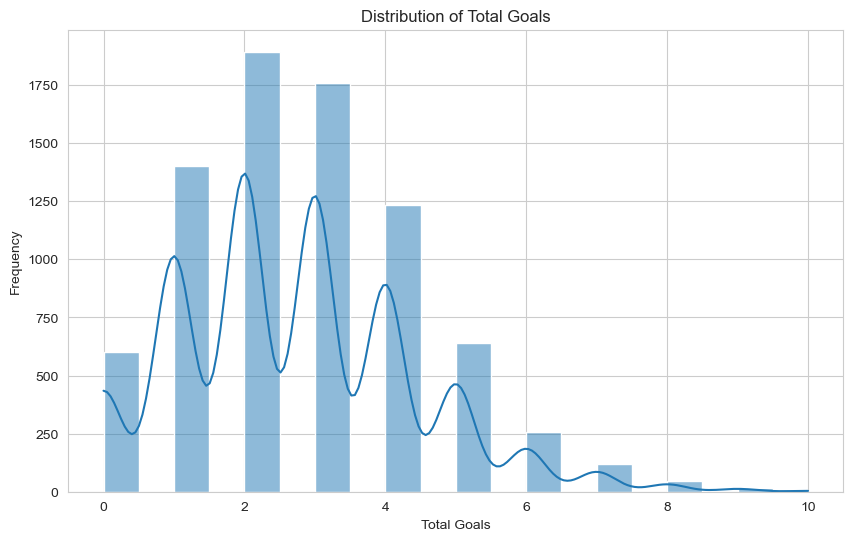

In [98]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalGoals'], bins=20, kde=True)
plt.title('Distribution of Total Goals')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
plt.show()

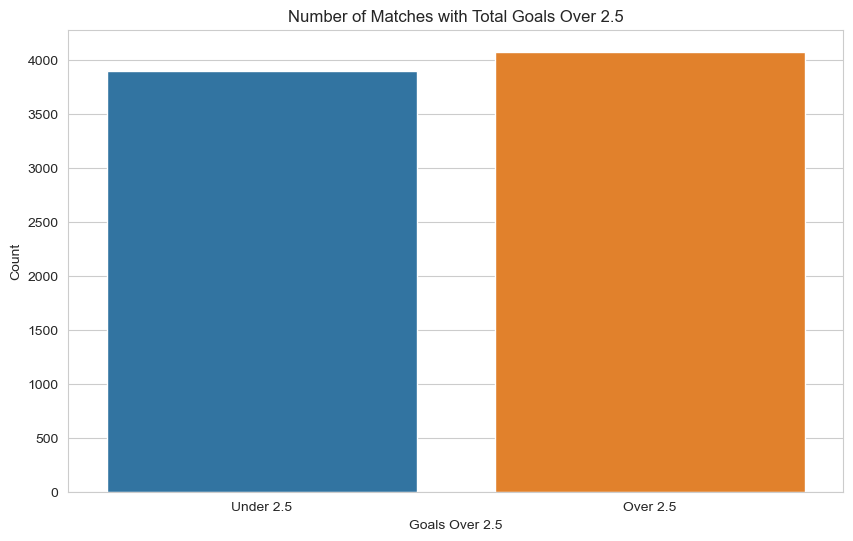

In [99]:
plt.figure(figsize=(10, 6))
sns.countplot(x='GoalsOver2_5', data=df)
plt.title('Number of Matches with Total Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Count')
plt.xticks([0, 1], ['Under 2.5', 'Over 2.5'])
plt.show()

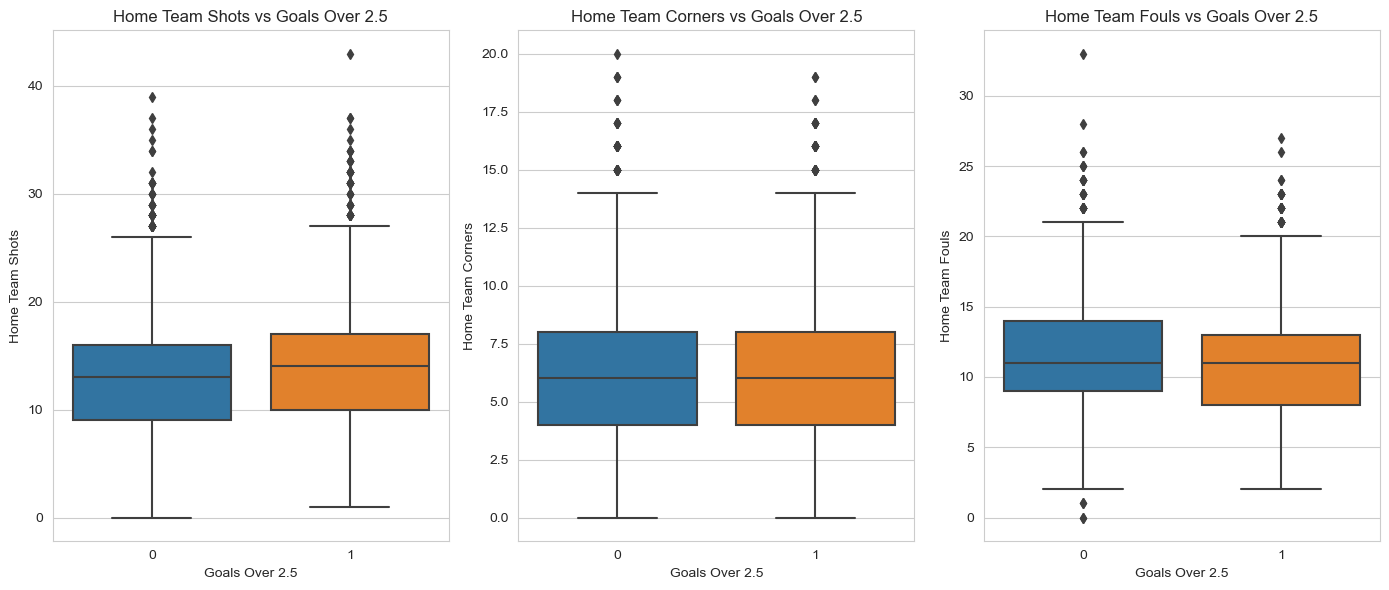

In [100]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='HS', data=df)
plt.title('Home Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Shots')

plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='HC', data=df)
plt.title('Home Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Corners')

plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='HF', data=df)
plt.title('Home Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Fouls')

plt.tight_layout()
plt.show()

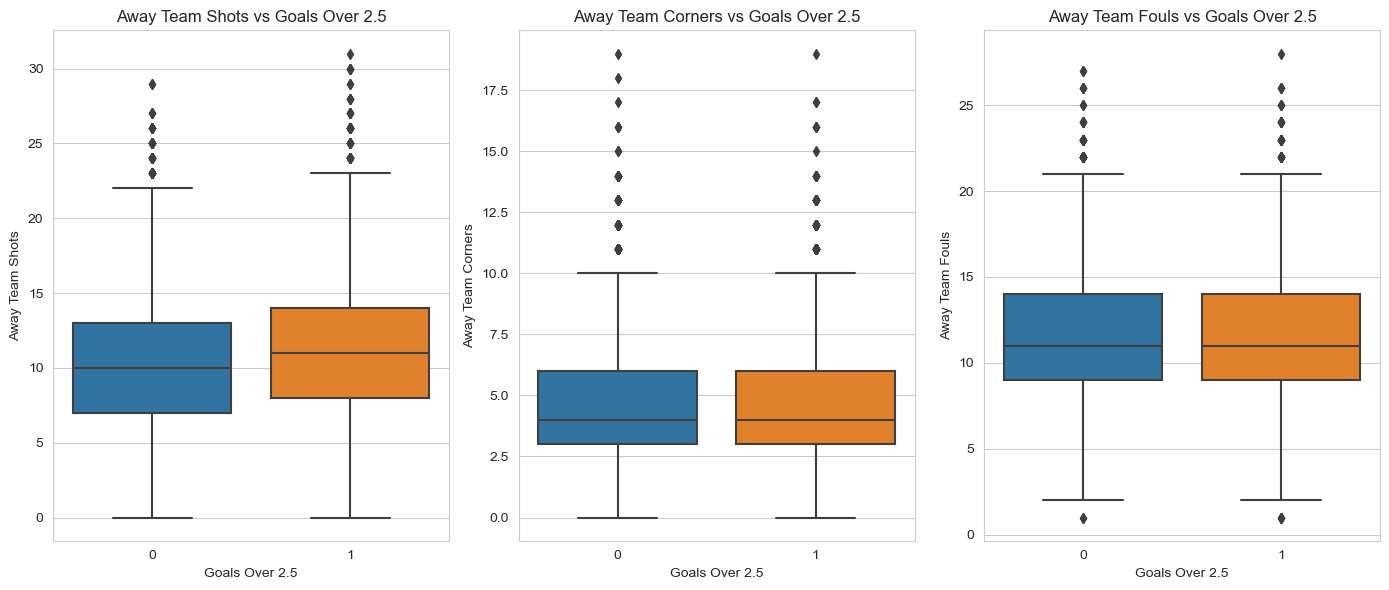

In [101]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='AS', data=df)
plt.title('Away Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Shots')

plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='AC', data=df)
plt.title('Away Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Corners')

plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='AF', data=df)
plt.title('Away Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Fouls')

plt.tight_layout()
plt.show()

In [102]:
print(df[['HomeTeam_mean_FTHG', 'AwayTeam_mean_FTAG']].head())

   HomeTeam_mean_FTHG  AwayTeam_mean_FTAG
0            2.120907            1.127907
1            1.359551            1.449749
2            1.537500            0.894737
3            1.476454            0.972603
4            1.278689            1.061453


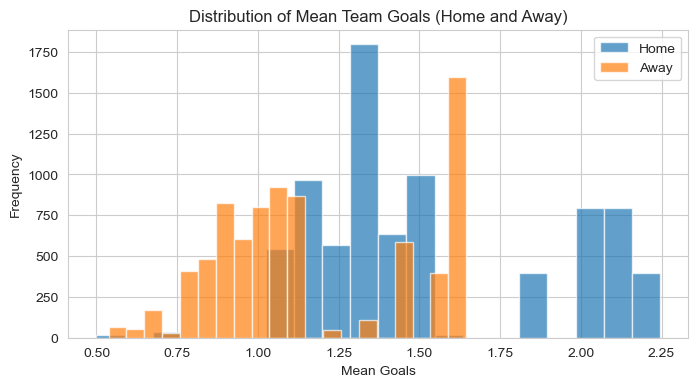

In [103]:
plt.figure(figsize=(8,4))
plt.hist(df['HomeTeam_mean_FTHG'], bins=20, alpha=0.7, label='Home')
plt.hist(df['AwayTeam_mean_FTAG'], bins=20, alpha=0.7, label='Away')
plt.xlabel('Mean Goals')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Team Goals (Home and Away)')
plt.legend()
plt.show()

In [104]:
odds_columns = [
    'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'B365H', 'B365D', 'B365A', 
    'AvgH', 'AvgD', 'AvgA', 'MaxH', 'MaxD', 'MaxA',
    'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5',
    'GB>2.5', 'GB<2.5', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5',
    'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5'
]
df[odds_columns].isnull().sum()

IWH            0
IWD            0
IWA            0
WHH            0
WHD            0
WHA            0
B365H          0
B365D          0
B365A          0
AvgH        6248
AvgD        6248
AvgA        6248
MaxH        6248
MaxD        6248
MaxA        6248
BbOU        2755
BbMx>2.5    2755
BbAv>2.5    2755
BbMx<2.5    2755
BbAv<2.5    2755
GB>2.5      6931
GB<2.5      6931
B365>2.5    5345
B365<2.5    5345
P>2.5       6249
P<2.5       6249
Max>2.5     6248
Max<2.5     6248
Avg>2.5     6248
Avg<2.5     6248
dtype: int64

In [105]:
drop_odds_columns = [
    'AvgH', 'AvgD', 'AvgA', 'MaxH', 'MaxD', 'MaxA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5',
    'BbMx<2.5', 'BbAv<2.5', 'GB>2.5', 'GB<2.5', 'P>2.5', 'P<2.5',
    'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5'
]
df = df.drop(columns=[col for col in drop_odds_columns if col in df.columns])

In [106]:
df['has_ou_odds'] = df[['B365>2.5', 'B365<2.5']].notnull().all(axis=1)

In [107]:
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,...,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds
0,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,5.0,11.0,...,0,0,0,0,0,0,0,0,0,False
1,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,9.0,6.0,...,0,0,0,1,0,0,0,0,0,False
2,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,12.0,2.0,...,0,0,0,0,1,0,0,0,0,False
3,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,14.0,8.0,...,0,0,0,0,0,0,0,1,0,False
4,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,9.0,16.0,...,0,0,0,0,0,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7961,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,7.0,6.0,...,0,0,0,0,0,0,0,0,0,True
7962,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,11.0,2.0,...,0,0,0,1,0,0,0,0,0,True
7963,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,16.0,4.0,...,0,0,0,0,0,0,1,0,0,True
7964,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,10.0,8.0,...,0,0,0,0,0,0,0,0,0,True


In [108]:
df['has_ou_odds'] = df['has_ou_odds'].astype(int)

In [109]:
df.to_csv('cleaned_data.csv', index=False)

# second Phase / reacent form

In [110]:
filePath = 'cleaned_data.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,...,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds
0,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,5.0,11.0,...,0,0,0,0,0,0,0,0,0,0
1,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,9.0,6.0,...,0,0,0,1,0,0,0,0,0,0
2,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,12.0,2.0,...,0,0,0,0,1,0,0,0,0,0
3,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,14.0,8.0,...,0,0,0,0,0,0,0,1,0,0
4,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,9.0,16.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7961,1.0,0.0,H,0.0,0.0,D,S Attwell,13.0,7.0,6.0,...,0,0,0,0,0,0,0,0,0,1
7962,1.0,4.0,A,0.0,1.0,A,A Taylor,19.0,11.0,2.0,...,0,0,0,1,0,0,0,0,0,1
7963,2.0,1.0,H,1.0,0.0,H,S Hooper,13.0,16.0,4.0,...,0,0,0,0,0,0,1,0,0,1
7964,2.0,1.0,H,1.0,1.0,D,R Jones,21.0,10.0,8.0,...,0,0,0,0,0,0,0,0,0,1


In [111]:
print(df[['HomeTeam', 'AwayTeam', 'GoalsOver2_5']].head())

     HomeTeam     AwayTeam  GoalsOver2_5
0     Arsenal  Aston Villa             0
1      Bolton    Tottenham             0
2     Everton      Watford             1
3   Newcastle        Wigan             1
4  Portsmouth    Blackburn             1


In [113]:
print(df.columns.tolist())

['FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'B365H', 'B365D', 'B365A', 'B365>2.5', 'B365<2.5', 'Date', 'Season', 'Year', 'Month', 'DayOfWeek', 'TotalGoals', 'GoalsOver2_5', 'HomeTeam_mean_FTHG', 'AwayTeam_mean_FTAG', 'HomeTeam', 'AwayTeam', 'HomeTeam_Arsenal', 'HomeTeam_Aston Villa', 'HomeTeam_Birmingham', 'HomeTeam_Blackburn', 'HomeTeam_Blackpool', 'HomeTeam_Bolton', 'HomeTeam_Bournemouth', 'HomeTeam_Brentford', 'HomeTeam_Brighton', 'HomeTeam_Burnley', 'HomeTeam_Cardiff', 'HomeTeam_Charlton', 'HomeTeam_Chelsea', 'HomeTeam_Crystal Palace', 'HomeTeam_Derby', 'HomeTeam_Everton', 'HomeTeam_Fulham', 'HomeTeam_Huddersfield', 'HomeTeam_Hull', 'HomeTeam_Leeds', 'HomeTeam_Leicester', 'HomeTeam_Liverpool', 'HomeTeam_Luton', 'HomeTeam_Man City', 'HomeTeam_Man United', 'HomeTeam_Middlesbrough', 'HomeTeam_Newcastle', 'HomeTeam_Norwich', "HomeTeam_Nott'm Forest", 'HomeTe

In [114]:
with open("feature_list.txt", "w") as f:
    for col in df.columns:
        f.write(f"{col}\n")

| Feature                  | Type         | Pre-Match? | Description                                                           |
|--------------------------|--------------|------------|-----------------------------------------------------------------------|
| Date                     | Date         | Yes        | Match date                                                            |
| FTHG                     | Numeric      | No         | Full time home goals (outcome/leakage)                                |
| FTAG                     | Numeric      | No         | Full time away goals (outcome/leakage)                                |
| FTR                      | Categorical  | No         | Full time result (H/D/A, outcome/leakage)                             |
| HTHG                     | Numeric      | No         | Half time home goals (outcome/leakage)                                |
| HTAG                     | Numeric      | No         | Half time away goals (outcome/leakage)                                |
| HTR                      | Categorical  | No         | Half time result (H/D/A, outcome/leakage)                             |
| Referee                  | Categorical  | Yes        | Name of referee                                                       |
| HS                       | Numeric      | No         | Home team shots (post-match)                                          |
| AS                       | Numeric      | No         | Away team shots (post-match)                                          |
| HST                      | Numeric      | No         | Home shots on target (post-match)                                     |
| AST                      | Numeric      | No         | Away shots on target (post-match)                                     |
| HC                       | Numeric      | No         | Home corners (post-match)                                             |
| AC                       | Numeric      | No         | Away corners (post-match)                                             |
| HF                       | Numeric      | No         | Home fouls (post-match)                                               |
| AF                       | Numeric      | No         | Away fouls (post-match)                                               |
| HY                       | Numeric      | No         | Home yellow cards (post-match)                                        |
| AY                       | Numeric      | No         | Away yellow cards (post-match)                                        |
| HR                       | Numeric      | No         | Home red cards (post-match)                                           |
| AR                       | Numeric      | No         | Away red cards (post-match)                                           |
| IWH                      | Numeric      | Yes        | Interwetten odds home win (pre-match)                                 |
| IWD                      | Numeric      | Yes        | Interwetten odds draw (pre-match)                                     |
| IWA                      | Numeric      | Yes        | Interwetten odds away win (pre-match)                                 |
| WHH                      | Numeric      | Yes        | William Hill odds home win (pre-match)                                |
| WHD                      | Numeric      | Yes        | William Hill odds draw (pre-match)                                    |
| WHA                      | Numeric      | Yes        | William Hill odds away win (pre-match)                                |
| B365H                    | Numeric      | Yes        | Bet365 odds home win (pre-match)                                      |
| B365D                    | Numeric      | Yes        | Bet365 odds draw (pre-match)                                          |
| B365A                    | Numeric      | Yes        | Bet365 odds away win (pre-match)                                      |
| B365>2.5                 | Numeric      | Yes        | Bet365 odds over 2.5 goals (pre-match, may be missing)                |
| B365<2.5                 | Numeric      | Yes        | Bet365 odds under 2.5 goals (pre-match, may be missing)               |
| has_ou_odds              | Numeric      | Yes        | 1 if both B365>2.5 and B365<2.5 present, else 0                       |
| Year                     | Numeric      | Yes        | Year of match                                                         |
| Month                    | Numeric      | Yes        | Month of match                                                        |
| DayOfWeek                | Numeric      | Yes        | Day of week (0=Monday, etc.)                                          |
| TotalGoals               | Numeric      | No         | Total goals (outcome/leakage)                                         |
| GoalsOver2_5             | Numeric      | No         | Target: 1 if over 2.5 goals, else 0 (leakage)                         |
| HomeTeam_mean_FTHG       | Numeric      | Yes        | Average home team goals (should be pre-match form, check how computed) |
| AwayTeam_mean_FTAG       | Numeric      | Yes        | Average away team goals (should be pre-match form, check how computed) |
| HomeTeam                 | Categorical  | Yes        | Home team label                                                       |
| AwayTeam                 | Categorical  | Yes        | Away team label                                                       |
| HomeTeam_*               | One-hot      | Yes        | Home team identity (one-hot encoded)                                  |
| AwayTeam_*               | One-hot      | Yes        | Away team identity (one-hot encoded)                                  |
| FTR_A                    | One-hot      | No         | Full-time result: away win (outcome/leakage)                          |
| FTR_D                    | One-hot      | No         | Full-time result: draw (outcome/leakage)                              |
| FTR_H                    | One-hot      | No         | Full-time result: home win (outcome/leakage)                          |
| HTR_A                    | One-hot      | No         | Half-time result: away (outcome/leakage)                              |
| HTR_D                    | One-hot      | No         | Half-time result: draw (outcome/leakage)                              |
| HTR_H                    | One-hot      | No         | Half-time result: home (outcome/leakage)                              |

In [115]:
print(sorted(df['HomeTeam'].unique()))
print(sorted(df['AwayTeam'].unique()))

['Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn', 'Blackpool', 'Bolton', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Cardiff', 'Charlton', 'Chelsea', 'Crystal Palace', 'Derby', 'Everton', 'Fulham', 'Huddersfield', 'Hull', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Middlesbrough', 'Newcastle', 'Norwich', "Nott'm Forest", 'Portsmouth', 'QPR', 'Reading', 'Sheffield United', 'Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wigan', 'Wolves']
['Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn', 'Blackpool', 'Bolton', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Cardiff', 'Charlton', 'Chelsea', 'Crystal Palace', 'Derby', 'Everton', 'Fulham', 'Huddersfield', 'Hull', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Middlesbrough', 'Newcastle', 'Norwich', "Nott'm Forest", 'Portsmouth', 'QPR', 'Reading', 'Sheffield United', 'Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Totte

In [116]:
def add_recent_form_features(df, n_matches=5):
    base = df.copy()
    base['Date'] = pd.to_datetime(base['Date'])
    base = base.sort_values('Date')

    home_df = base[['Date', 'HomeTeam', 'FTHG', 'FTAG', 'FTR']].rename(
        columns={'HomeTeam': 'Team', 'FTHG': 'GoalsFor', 'FTAG': 'GoalsAgainst'})
    away_df = base[['Date', 'AwayTeam', 'FTAG', 'FTHG', 'FTR']].rename(
        columns={'AwayTeam': 'Team', 'FTAG': 'GoalsFor', 'FTHG': 'GoalsAgainst'})

    results = pd.concat([home_df, away_df], ignore_index=True)
    results = results.sort_values(['Team', 'Date'])

    def get_points(row):
        if row['GoalsFor'] > row['GoalsAgainst']:
            return 3
        elif row['GoalsFor'] == row['GoalsAgainst']:
            return 1
        else:
            return 0
    results['Points'] = results.apply(get_points, axis=1)

    results['RollingGF'] = results.groupby('Team')['GoalsFor'].transform(lambda x: x.shift().rolling(n_matches, min_periods=1).mean())
    results['RollingGA'] = results.groupby('Team')['GoalsAgainst'].transform(lambda x: x.shift().rolling(n_matches, min_periods=1).mean())
    results['RollingPoints'] = results.groupby('Team')['Points'].transform(lambda x: x.shift().rolling(n_matches, min_periods=1).sum())

    def get_form(row, team_col):
        team = row[team_col]
        date = row['Date']
        row_form = results[(results['Team'] == team) & (results['Date'] < date)].sort_values('Date').tail(1)
        if row_form.empty:
            return pd.Series([np.nan, np.nan, np.nan])
        return row_form[['RollingGF', 'RollingGA', 'RollingPoints']].values[0]

    base[['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts']] = base.apply(
        lambda row: get_form(row, 'HomeTeam'), axis=1, result_type='expand')
    base[['AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']] = base.apply(
        lambda row: get_form(row, 'AwayTeam'), axis=1, result_type='expand')

    return base

In [117]:
df_with_form = add_recent_form_features(df, n_matches=5)

In [120]:
df_with_form.head(90)

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts
382,2.0,2.0,D,1.0,0.0,H,N Barry,13.0,10.0,9.0,5.0,10.0,5.0,18.0,4.0,1.0,1.0,0.0,0.0,2.30,3.0,2.70,2.30,3.1,2.75,2.250,3.25,2.750,NaN,NaN,2002-08-17,2002-03,2002,8,5,4.0,1,1.537500,1.449749,Everton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
381,2.0,3.0,A,2.0,1.0,H,G Barber,5.0,21.0,5.0,12.0,3.0,6.0,10.0,12.0,0.0,3.0,1.0,0.0,2.90,3.0,2.20,2.75,3.1,2.30,2.800,3.25,2.200,NaN,NaN,2002-08-17,2002-03,2002,8,5,5.0,1,1.337079,1.605528,Charlton,Chelsea,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
386,0.0,0.0,D,0.0,0.0,D,B Knight,12.0,11.0,5.0,5.0,3.0,4.0,11.0,14.0,0.0,0.0,0.0,0.0,2.20,3.0,2.90,2.62,3.1,2.37,2.250,3.25,2.750,NaN,NaN,2002-08-17,2002-03,2002,8,5,0.0,0,1.374046,0.841727,Southampton,Middlesbrough,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
383,4.0,1.0,H,3.0,1.0,H,A Wiley,13.0,3.0,6.0,1.0,7.0,4.0,16.0,12.0,1.0,2.0,0.0,0.0,1.80,3.1,3.80,1.72,3.2,4.33,1.727,3.25,4.333,NaN,NaN,2002-08-17,2002-03,2002,8,5,5.0,1,1.366197,1.027624,Fulham,Bolton,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
384,3.0,0.0,H,2.0,0.0,H,G Poll,13.0,18.0,8.0,10.0,2.0,7.0,13.0,13.0,1.0,1.0,0.0,0.0,1.70,3.2,4.20,1.66,3.3,4.50,1.667,3.40,4.500,NaN,NaN,2002-08-17,2002-03,2002,8,5,3.0,1,1.260870,1.645000,Leeds,Man City,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [121]:
cols = ['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts', 'AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']
print(df_with_form[cols].isna().sum())

HomeRecentGF     41
HomeRecentGA     41
HomeRecentPts    41
AwayRecentGF     45
AwayRecentGA     45
AwayRecentPts    45
dtype: int64


In [122]:
cols = ['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts', 'AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']
df_with_form = df_with_form.dropna(subset=cols)
print(df_with_form.shape)

(7901, 134)


In [123]:
df_with_form.columns.tolist()

['FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'Referee',
 'HS',
 'AS',
 'HST',
 'AST',
 'HC',
 'AC',
 'HF',
 'AF',
 'HY',
 'AY',
 'HR',
 'AR',
 'IWH',
 'IWD',
 'IWA',
 'WHH',
 'WHD',
 'WHA',
 'B365H',
 'B365D',
 'B365A',
 'B365>2.5',
 'B365<2.5',
 'Date',
 'Season',
 'Year',
 'Month',
 'DayOfWeek',
 'TotalGoals',
 'GoalsOver2_5',
 'HomeTeam_mean_FTHG',
 'AwayTeam_mean_FTAG',
 'HomeTeam',
 'AwayTeam',
 'HomeTeam_Arsenal',
 'HomeTeam_Aston Villa',
 'HomeTeam_Birmingham',
 'HomeTeam_Blackburn',
 'HomeTeam_Blackpool',
 'HomeTeam_Bolton',
 'HomeTeam_Bournemouth',
 'HomeTeam_Brentford',
 'HomeTeam_Brighton',
 'HomeTeam_Burnley',
 'HomeTeam_Cardiff',
 'HomeTeam_Charlton',
 'HomeTeam_Chelsea',
 'HomeTeam_Crystal Palace',
 'HomeTeam_Derby',
 'HomeTeam_Everton',
 'HomeTeam_Fulham',
 'HomeTeam_Huddersfield',
 'HomeTeam_Hull',
 'HomeTeam_Leeds',
 'HomeTeam_Leicester',
 'HomeTeam_Liverpool',
 'HomeTeam_Luton',
 'HomeTeam_Man City',
 'HomeTeam_Man United',
 'HomeTeam_Middlesbrough',
 'HomeTea

In [124]:
def ocd_data_check(df):
    print("===== OCD Data Check Report (Model-Ready) =====")
    print(f"Shape: {df.shape}")
    
    print("\n1. Columns with missing values:")
    na = df.isna().sum()
    na = na[na > 0]
    print(na if not na.empty else "None")
    
    print("\n2. Duplicate rows (entire row):", df.duplicated().sum())
    
    print("\n3. Date range and future dates:")
    if 'Date' in df.columns:
        print("   Min:", df['Date'].min(), "Max:", df['Date'].max())
        print("   Future dates:", (pd.to_datetime(df['Date']) > pd.Timestamp.today()).sum())
    else:
        print("   No 'Date' column found.")
  
    home_teams = [c for c in df.columns if c.startswith('HomeTeam_')]
    away_teams = [c for c in df.columns if c.startswith('AwayTeam_')]
    print("\n4. Team one-hot columns:")
    print(f"   Number of HomeTeam_* columns: {len(home_teams)}")
    print(f"   Number of AwayTeam_* columns: {len(away_teams)}")
    print(f"   HomeTeam teams: {[c.replace('HomeTeam_','') for c in home_teams]}")
    print(f"   AwayTeam teams: {[c.replace('AwayTeam_','') for c in away_teams]}")
    missing_home = set([c.replace('AwayTeam_','') for c in away_teams]) - set([c.replace('HomeTeam_','') for c in home_teams])
    missing_away = set([c.replace('HomeTeam_','') for c in home_teams]) - set([c.replace('AwayTeam_','') for c in away_teams])
    if missing_home or missing_away:
        print(f"   Teams missing from HomeTeam: {missing_home}")
        print(f"   Teams missing from AwayTeam: {missing_away}")
    else:
        print("   HomeTeam and AwayTeam one-hot columns match.")

    print("\n5. Unique one-hot team per row check:")
    if home_teams and away_teams:
        home_sum = df[home_teams].sum(axis=1)
        away_sum = df[away_teams].sum(axis=1)
        print("   Rows with != 1 HomeTeam one-hot:", (home_sum != 1).sum())
        print("   Rows with != 1 AwayTeam one-hot:", (away_sum != 1).sum())
    else:
        print("   One-hot columns for team not found.")
    
    odds_cols = [c for c in df.columns if c in ['IWH','IWD','IWA','WHH','WHD','WHA']]
    print("\n6. Bookmaker odds columns stats:")
    if odds_cols:
        print(df[odds_cols].describe())
        for col in odds_cols:
            print(f"   {col} <= 0 values:", (df[col] <= 0).sum())
    else:
        print("   No bookmaker odds columns found.")
 
    for cal_col in ['Year','Month','DayOfWeek']:
        if cal_col in df.columns:
            print(f"\n7. {cal_col} column: min={df[cal_col].min()}, max={df[cal_col].max()}")
        else:
            print(f"\n7. {cal_col} column not found.")
    
    recent_cols = ['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts', 'AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']
    existing_recent_cols = [c for c in recent_cols if c in df.columns]
    print("\n8. Recent form columns sanity:")
    if existing_recent_cols:
        print(df[existing_recent_cols].describe())
        for col in existing_recent_cols:
            print(f"   {col} < 0 values:", (df[col] < 0).sum())
    else:
        print("   No recent form columns found.")
    
    for mean_col in ['HomeTeam_mean_FTHG','AwayTeam_mean_FTAG']:
        if mean_col in df.columns:
            print(f"\n9. {mean_col}: min={df[mean_col].min()}, max={df[mean_col].max()}, mean={df[mean_col].mean()}")
        else:
            print(f"\n9. {mean_col} column not found.")
   
    print("\n10. HomeTeam/AwayTeam string columns sanity:")
    if 'HomeTeam' in df.columns and 'AwayTeam' in df.columns:
        print(f"   Number of unique HomeTeam: {df['HomeTeam'].nunique()}")
        print(f"   Number of unique AwayTeam: {df['AwayTeam'].nunique()}")
        print(f"   Example HomeTeams: {df['HomeTeam'].unique()[:10]}")
        print(f"   Example AwayTeams: {df['AwayTeam'].unique()[:10]}")
        # Check for missing or blank values
        print(f"   Missing HomeTeam values: {df['HomeTeam'].isna().sum() + (df['HomeTeam'] == '').sum()}")
        print(f"   Missing AwayTeam values: {df['AwayTeam'].isna().sum() + (df['AwayTeam'] == '').sum()}")
        # Check for mismatches with one-hot encoding
        home_onehot_set = set([c.replace('HomeTeam_', '') for c in home_teams])
        away_onehot_set = set([c.replace('AwayTeam_', '') for c in away_teams])
        home_str_set = set(df['HomeTeam'].unique())
        away_str_set = set(df['AwayTeam'].unique())
        print(f"   HomeTeam string col teams not in one-hot: {home_str_set - home_onehot_set}")
        print(f"   AwayTeam string col teams not in one-hot: {away_str_set - away_onehot_set}")
    else:
        print("   HomeTeam and/or AwayTeam string columns not found.")
    
    print("\n===== End of OCD Data Check (Model-Ready) =====")

In [125]:
ocd_data_check(df_with_form)

===== OCD Data Check Report (Model-Ready) =====
Shape: (7901, 134)

1. Columns with missing values:
B365>2.5    5295
B365<2.5    5295
dtype: int64

2. Duplicate rows (entire row): 0

3. Date range and future dates:
   Min: 2002-08-27 00:00:00 Max: 2024-01-02 00:00:00
   Future dates: 0

4. Team one-hot columns:
   Number of HomeTeam_* columns: 44
   Number of AwayTeam_* columns: 44
   HomeTeam teams: ['mean_FTHG', 'Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn', 'Blackpool', 'Bolton', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Cardiff', 'Charlton', 'Chelsea', 'Crystal Palace', 'Derby', 'Everton', 'Fulham', 'Huddersfield', 'Hull', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Middlesbrough', 'Newcastle', 'Norwich', "Nott'm Forest", 'Portsmouth', 'QPR', 'Reading', 'Sheffield United', 'Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wigan', 'Wolves']
   AwayTeam teams: ['mean_FTAG', 'Arsenal', 'Aston V

In [127]:
print(df_with_form[['HomeTeam_mean_FTHG', 'AwayTeam_mean_FTAG']])

     HomeTeam_mean_FTHG  AwayTeam_mean_FTAG
400            2.120907            0.873469
401            1.337079            1.449749
404            1.537500            0.836066
405            1.260870            0.864253
406            1.374046            1.605528
..                  ...                 ...
936            1.334311            0.919753
941            1.366197            1.621554
942            1.842105            1.120968
943            2.077889            1.027778
944            1.445087            1.104839

[7901 rows x 2 columns]


In [128]:
home_onehot_cols = [col for col in df_with_form.columns
                    if col.startswith('HomeTeam_') and 'mean' not in col]

away_onehot_cols = [col for col in df_with_form.columns
                    if col.startswith('AwayTeam_') and 'mean' not in col]

In [129]:
print(len(home_onehot_cols)) 
print(len(away_onehot_cols)) 
print(home_onehot_cols)
print(away_onehot_cols)  

43
43
['HomeTeam_Arsenal', 'HomeTeam_Aston Villa', 'HomeTeam_Birmingham', 'HomeTeam_Blackburn', 'HomeTeam_Blackpool', 'HomeTeam_Bolton', 'HomeTeam_Bournemouth', 'HomeTeam_Brentford', 'HomeTeam_Brighton', 'HomeTeam_Burnley', 'HomeTeam_Cardiff', 'HomeTeam_Charlton', 'HomeTeam_Chelsea', 'HomeTeam_Crystal Palace', 'HomeTeam_Derby', 'HomeTeam_Everton', 'HomeTeam_Fulham', 'HomeTeam_Huddersfield', 'HomeTeam_Hull', 'HomeTeam_Leeds', 'HomeTeam_Leicester', 'HomeTeam_Liverpool', 'HomeTeam_Luton', 'HomeTeam_Man City', 'HomeTeam_Man United', 'HomeTeam_Middlesbrough', 'HomeTeam_Newcastle', 'HomeTeam_Norwich', "HomeTeam_Nott'm Forest", 'HomeTeam_Portsmouth', 'HomeTeam_QPR', 'HomeTeam_Reading', 'HomeTeam_Sheffield United', 'HomeTeam_Southampton', 'HomeTeam_Stoke', 'HomeTeam_Sunderland', 'HomeTeam_Swansea', 'HomeTeam_Tottenham', 'HomeTeam_Watford', 'HomeTeam_West Brom', 'HomeTeam_West Ham', 'HomeTeam_Wigan', 'HomeTeam_Wolves']
['AwayTeam_Arsenal', 'AwayTeam_Aston Villa', 'AwayTeam_Birmingham', 'AwayTea

In [130]:
for col in ['B365>2.5', 'B365<2.5']:
    median = df_with_form[col].median()
    df_with_form[f'{col}_missing'] = df_with_form[col].isna().astype(int)
    df_with_form[col] = df_with_form[col].fillna(median)

In [131]:
df_with_form

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing
400,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,3.0,0.0,1.0,0.0,1,1
401,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,0.0,2.0,2.0,1.0,1,1
404,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,1.0,0.0,2.0,0.0,1,1
405,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,1.0,0,1.260870,0.864253,Leeds,Sunderland,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3.0,0.0,3.0,0.0,0.0,1.0,1,1
406,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,4.0,3.0,5.0,6.0,16.0,11.0,2.0,1.0,0.0,0.0,3.20,3.10,2.00,3.20,3.20,2.00,3.00,3.25,2.10,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.374046,1.605528,Southampton,Chelsea,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,3.0,2

In [132]:
print(df_with_form[['B365>2.5', 'B365<2.5']].isnull().sum())

B365>2.5    0
B365<2.5    0
dtype: int64


In [133]:
df_with_form.to_csv('recentForm_data.csv', index=False)

# Phase 3 head to head / team strength position

In [134]:
filePath = 'recentForm_data.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,3.0,0.0,1.0,0.0,1,1
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,0.0,2.0,2.0,1.0,1,1
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,1.0,0.0,2.0,0.0,1,1
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,1.0,0,1.260870,0.864253,Leeds,Sunderland,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3.0,0.0,3.0,0.0,0.0,1.0,1,1
4,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,4.0,3.0,5.0,6.0,16.0,11.0,2.0,1.0,0.0,0.0,3.20,3.10,2.00,3.20,3.20,2.00,3.00,3.25,2.10,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.374046,1.605528,Southampton,Chelsea,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,3.0,2.0,3.0,1,1

In [135]:
df = df.sort_values('Date')

h2h_home_wins = []

for idx, row in df.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
    match_date = row['Date']

    prev_matches = df[
        (((df['HomeTeam'] == home) & (df['AwayTeam'] == away)) |
         ((df['HomeTeam'] == away) & (df['AwayTeam'] == home)))
        & (df['Date'] < match_date)
    ].sort_values('Date', ascending=False).head(5)

    home_wins = ((prev_matches['HomeTeam'] == home) & (prev_matches['FTHG'] > prev_matches['FTAG'])).sum()
    h2h_home_wins.append(home_wins)

df['h2h_home_wins_last5'] = h2h_home_wins

In [136]:
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing,h2h_home_wins_last5
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,3.0,0.0,1.0,0.0,1,1,0
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,0.0,2.0,2.0,1.0,1,1,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,1.0,0.0,2.0,0.0,1,1,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,1.0,0,1.260870,0.864253,Leeds,Sunderland,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3.0,0.0,3.0,0.0,0.0,1.0,1,1,0
4,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,4.0,3.0,5.0,6.0,16.0,11.0,2.0,1.0,0.0,0.0,3.20,3.10,2.00,3.20,3.20,2.00,3.00,3.25,2.10,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.374046,1.605528,Southampton,Chelsea,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [137]:
team_stats = {}

home_positions = []
away_positions = []

for idx, row in df.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
  
    league_table = []
    for team, stats in team_stats.items():
        league_table.append({
            'team': team,
            'points': stats['points'],
            'gd': stats['gd'],
            'scored': stats['scored']
        })
    table_df = pd.DataFrame(league_table)
    if not table_df.empty:
        table_df = table_df.sort_values(['points', 'gd', 'scored'], ascending=[False, False, False])
        table_df['position'] = range(1, len(table_df) + 1)
        home_pos = table_df[table_df['team'] == home]['position'].values[0] if home in table_df['team'].values else len(table_df) + 1
        away_pos = table_df[table_df['team'] == away]['position'].values[0] if away in table_df['team'].values else len(table_df) + 1
    else:
        home_pos = away_pos = 1 

    home_positions.append(home_pos)
    away_positions.append(away_pos)

    home_goals = row['FTHG']
    away_goals = row['FTAG']

    for team in [home, away]:
        if team not in team_stats:
            team_stats[team] = {'points': 0, 'gd': 0, 'scored': 0}
    
    if home_goals > away_goals:
        team_stats[home]['points'] += 3
    elif home_goals < away_goals:
        team_stats[away]['points'] += 3
    else:
        team_stats[home]['points'] += 1
        team_stats[away]['points'] += 1
  
    team_stats[home]['gd'] += home_goals - away_goals
    team_stats[away]['gd'] += away_goals - home_goals
    team_stats[home]['scored'] += home_goals
    team_stats[away]['scored'] += away_goals

df['home_league_position'] = home_positions
df['away_league_position'] = away_positions
df['position_diff'] = df['home_league_position'] - df['away_league_position']

In [138]:
print(df[['Date', 'HomeTeam', 'AwayTeam', 'home_league_position', 'away_league_position', 'position_diff']].head(10))
print(df[['Date', 'HomeTeam', 'AwayTeam', 'home_league_position', 'away_league_position', 'position_diff']].tail(10))

         Date       HomeTeam    AwayTeam  home_league_position  \
0  2002-08-27        Arsenal   West Brom                     1   
1  2002-08-27       Charlton   Tottenham                     3   
2  2002-08-28        Everton  Birmingham                     5   
3  2002-08-28          Leeds  Sunderland                     7   
4  2002-08-28    Southampton     Chelsea                     9   
5  2002-08-28      Blackburn   Liverpool                    11   
6  2002-08-28    Aston Villa    Man City                    13   
7  2002-08-31       West Ham    Charlton                    15   
8  2002-08-31      West Brom      Fulham                    15   
9  2002-08-31  Middlesbrough   Blackburn                    17   

   away_league_position  position_diff  
0                     1              0  
1                     3              0  
2                     5              0  
3                     7              0  
4                     9              0  
5                    11    

In [139]:
print(df['home_league_position'].describe())
print(df['away_league_position'].describe())
print(df['position_diff'].describe())

count    7901.000000
mean       13.660929
std         9.886973
min         1.000000
25%         6.000000
50%        11.000000
75%        20.000000
max        43.000000
Name: home_league_position, dtype: float64
count    7901.000000
mean       13.618150
std         9.865558
min         1.000000
25%         6.000000
50%        11.000000
75%        20.000000
max        43.000000
Name: away_league_position, dtype: float64
count    7901.000000
mean        0.042779
std        14.048260
min       -41.000000
25%        -9.000000
50%         1.000000
75%         9.000000
max        40.000000
Name: position_diff, dtype: float64


In [140]:
print(df[df['HomeTeam'] == "Chelsea"][['Date', 'HomeTeam', 'AwayTeam', 'home_league_position']].head(10))
print(df[df['AwayTeam'] == "Chelsea"][['Date', 'HomeTeam', 'AwayTeam', 'away_league_position']].head(10))

           Date HomeTeam       AwayTeam  home_league_position
15   2002-09-01  Chelsea        Arsenal                    11
31   2002-09-14  Chelsea      Newcastle                     8
49   2002-09-28  Chelsea       West Ham                     2
81   2002-10-26  Chelsea      West Brom                     6
101  2002-11-09  Chelsea     Birmingham                     5
112  2002-11-16  Chelsea  Middlesbrough                     3
129  2002-11-30  Chelsea     Sunderland                     4
159  2002-12-21  Chelsea    Aston Villa                     2
169  2002-12-26  Chelsea    Southampton                     2
200  2003-01-11  Chelsea       Charlton                     3
           Date       HomeTeam AwayTeam  away_league_position
4    2002-08-28    Southampton  Chelsea                     9
25   2002-09-11      Blackburn  Chelsea                    15
46   2002-09-23         Fulham  Chelsea                     7
65   2002-10-06      Liverpool  Chelsea                     9
73   200

In [141]:
print(df['home_league_position'].min(), df['home_league_position'].max())
print(df['away_league_position'].min(), df['away_league_position'].max())

1 43
1 43


In [142]:
df.to_csv('headToHaed_data.csv', index=False)

# Phase 4

In [3]:
filePath = 'headToHaed_data.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing,h2h_home_wins_last5,home_league_position,away_league_position,position_diff
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,3.0,0.0,1.0,0.0,1,1,0,1,1,0
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,0.0,2.0,2.0,1.0,1,1,0,3,3,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,1.0,0.0,2.0,0.0,1,1,0,5,5,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,1.0,0,1.260870,0.864253,Leeds,Sunderland,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3.0,0.0,3.0,0.0,0.0,1.0,1,1,0,7,7,0
4,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,4.0,3.0,5.0,6.0,16.0,11.0,2.0,1.0,0.0,0.0,3.20,3.10,2.00,3.20,3.20,2.00,3.00,3.25,2.10,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.374046,1.605528,Southampton,Chelsea,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0

In [4]:
N = 5

def home_points(row):
    if row['FTR'] == 'H':
        return 3
    elif row['FTR'] == 'D':
        return 1
    else:
        return 0

def away_points(row):
    if row['FTR'] == 'A':
        return 3
    elif row['FTR'] == 'D':
        return 1
    else:
        return 0

df['HomePts'] = df.apply(home_points, axis=1)
df['AwayPts'] = df.apply(away_points, axis=1)

df = df.sort_values('Date')

df['HomeRecentPts'] = (
    df.groupby('HomeTeam')['HomePts']
    .transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
)
df['AwayRecentPts'] = (
    df.groupby('AwayTeam')['AwayPts']
    .transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
)

print(df[['Date', 'HomeTeam', 'AwayTeam', 'HomePts', 'AwayPts', 'HomeRecentPts', 'AwayRecentPts']].head(10))

         Date       HomeTeam    AwayTeam  HomePts  AwayPts  HomeRecentPts  \
0  2002-08-27        Arsenal   West Brom        3        0            NaN   
1  2002-08-27       Charlton   Tottenham        0        3            NaN   
2  2002-08-28        Everton  Birmingham        1        1            NaN   
3  2002-08-28          Leeds  Sunderland        0        3            NaN   
4  2002-08-28    Southampton     Chelsea        1        1            NaN   
5  2002-08-28      Blackburn   Liverpool        1        1            NaN   
6  2002-08-28    Aston Villa    Man City        3        0            NaN   
7  2002-08-31       West Ham    Charlton        0        3            NaN   
8  2002-08-31      West Brom      Fulham        3        0            NaN   
9  2002-08-31  Middlesbrough   Blackburn        3        0            NaN   

   AwayRecentPts  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
5            NaN  
6            NaN  


In [5]:
print(df[df['HomeTeam'] == 'Arsenal'][['Date', 'HomeTeam', 'HomePts', 'HomeRecentPts']])

            Date HomeTeam  HomePts  HomeRecentPts
0     2002-08-27  Arsenal        3            NaN
17    2002-09-10  Arsenal        3            3.0
38    2002-09-21  Arsenal        3            6.0
61    2002-10-06  Arsenal        3            9.0
83    2002-10-26  Arsenal        0           12.0
...          ...      ...      ...            ...
7796  2023-10-28  Arsenal        3           11.0
7815  2023-11-11  Arsenal        3           11.0
7836  2023-12-02  Arsenal        3           13.0
7868  2023-12-17  Arsenal        3           13.0
7890  2023-12-28  Arsenal        0           15.0

[395 rows x 4 columns]


In [7]:
N = 5  

df['HomeGoalDiff'] = df['FTHG'] - df['FTAG']
df['AwayGoalDiff'] = df['FTAG'] - df['FTHG']

df['HomeRecentGoalDiff'] = (
    df.groupby('HomeTeam')['HomeGoalDiff']
      .transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
)

df['AwayRecentGoalDiff'] = (
    df.groupby('AwayTeam')['AwayGoalDiff']
      .transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
)

df['RecentGoalDiff'] = df['HomeRecentGoalDiff'] - df['AwayRecentGoalDiff']

In [8]:
N = 5

df = df.sort_values('Date')  # Ensure chronological order

df['HomeRecentShotsOnTarget'] = (
    df.groupby('HomeTeam')['HST']
    .transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
)
df['AwayRecentShotsOnTarget'] = (
    df.groupby('AwayTeam')['AST']
    .transform(lambda x: x.shift(1).rolling(N, min_periods=1).sum())
)

In [9]:
df['RecentShotsOnTargetDiff'] = df['HomeRecentShotsOnTarget'] - df['AwayRecentShotsOnTarget']

In [10]:
df['PosDiff'] = df['home_league_position'] - df['away_league_position']

In [11]:
df['B365>2.5_implied_prob'] = 1 / df['B365>2.5']
df['B365<2.5_implied_prob'] = 1 / df['B365<2.5']

In [12]:
df['OddsMargin'] = df['B365H'] / df['B365A']

In [13]:
df['OU_OddsMargin'] = df['B365>2.5'] / df['B365<2.5']

In [14]:
df['OverUnderRatio'] = df['B365>2.5'] / df['B365<2.5']

In [15]:
df['Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [16]:
def rolling_ref_aggression(subdf):
    # Shift by 1 to avoid using the current match (pre-match safe)
    agg = subdf[['HY', 'AY', 'HR', 'AR']].shift(1).sum(axis=1)
    return agg.rolling(10, min_periods=1).mean()

df = df.sort_values('Date')

df['RefereeAggression'] = (
    df.groupby('Referee')
      .apply(lambda subdf: rolling_ref_aggression(subdf))
      .reset_index(level=0, drop=True)
)

/var/folders/tk/jl3yfcz52s9020z4_8dbfkvw0000gn/T/ipykernel_4103/1290701103.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda subdf: rolling_ref_aggression(subdf))


In [17]:
df['EarlySeason'] = (df['Month'] <= 3).astype(int)

In [18]:
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing,h2h_home_wins_last5,home_league_position,away_league_position,position_diff,HomePts,AwayPts,HomeGoalDiff,AwayGoalDiff,HomeRecentGoalDiff,AwayRecentGoalDiff,RecentGoalDiff,HomeRecentShotsOnTarget,AwayRecentShotsOnTarget,RecentShotsOnTargetDiff,PosDiff,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,RefereeAggression,EarlySeason
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,NaN,0.0,1.0,NaN,1,1,0,1,1,0,3,0,3.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0.526316,0.523560,0.090000,0.994764,0.994764,0,0.0,0
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,NaN,2.0,2.0,NaN,1,1,0,3,3,0,0,3,-1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0.526316,0.523560,0.923077,0.994764,0.994764,0,0.0,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,NaN,0.0,2.0,NaN,1,1,0,5,5,0,1,1,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0.526316,0.523560,0.371111,0.994764,0.994764,0,0.0,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.91,2002-08

In [19]:
df = df.drop_duplicates()

In [20]:
for col in df.select_dtypes(include=['number']):
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object', 'category']):
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

Series([], dtype: int64)
Series([], dtype: float64)


In [22]:
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing,h2h_home_wins_last5,home_league_position,away_league_position,position_diff,HomePts,AwayPts,HomeGoalDiff,AwayGoalDiff,HomeRecentGoalDiff,AwayRecentGoalDiff,RecentGoalDiff,HomeRecentShotsOnTarget,AwayRecentShotsOnTarget,RecentShotsOnTargetDiff,PosDiff,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,RefereeAggression,EarlySeason
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,8.0,0.0,1.0,5.0,1,1,0,1,1,0,3,0,3.0,-3.0,2.0,-2.0,3.0,28.0,22.0,6.0,0,0.526316,0.523560,0.090000,0.994764,0.994764,0,0.0,0
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,8.0,2.0,2.0,5.0,1,1,0,3,3,0,0,3,-1.0,1.0,2.0,-2.0,3.0,28.0,22.0,6.0,0,0.526316,0.523560,0.923077,0.994764,0.994764,0,0.0,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,8.0,0.0,2.0,5.0,1,1,0,5,5,0,1,1,0.0,0.0,2.0,-2.0,3.0,28.0,22.0,6.0,0,0.526316,0.523560,0.371111,0.994764,0.994764,0,0.0,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.9

In [23]:
df.to_csv('test_data.csv', index=False)

# phase 5/ Data Integrity

In [4]:
filePath = 'headToHaed_data.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing,h2h_home_wins_last5,home_league_position,away_league_position,position_diff
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,6.0,1.0,1.0,9.0,9.0,3.0,2.0,0.0,0.0,1.20,5.00,10.00,1.16,5.50,12.00,1.17,5.50,13.00,1.90,1.91,2002-08-27,2002-03,2002,8,1,7.0,1,2.120907,0.873469,Arsenal,West Brom,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2.0,0.0,3.0,0.0,1.0,0.0,1,1,0,1,1,0
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,1.0,6.0,9.0,9.0,23.0,1.0,2.0,0.0,0.0,2.30,3.00,2.70,2.50,3.10,2.50,2.40,3.20,2.60,1.90,1.91,2002-08-27,2002-03,2002,8,1,1.0,0,1.337079,1.449749,Charlton,Tottenham,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,3.0,0.0,2.0,2.0,1.0,1,1,0,3,3,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,2.0,7.0,4.0,18.0,12.0,0.0,3.0,1.0,0.0,1.60,3.40,4.60,1.66,3.30,4.50,1.67,3.40,4.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.537500,0.836066,Everton,Birmingham,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,2.0,1.0,0.0,2.0,0.0,1,1,0,5,5,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,4.0,8.0,1.0,13.0,11.0,2.0,0.0,0.0,0.0,1.40,3.90,6.00,1.36,3.75,8.00,1.50,3.40,6.50,1.90,1.91,2002-08-28,2002-03,2002,8,2,1.0,0,1.260870,0.864253,Leeds,Sunderland,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3.0,0.0,3.0,0.0,0.0,1.0,1,1,0,7,7,0
4,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,4.0,3.0,5.0,6.0,16.0,11.0,2.0,1.0,0.0,0.0,3.20,3.10,2.00,3.20,3.20,2.00,3.00,3.25,2.10,1.90,1.91,2002-08-28,2002-03,2002,8,2,2.0,0,1.374046,1.605528,Southampton,Chelsea,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0

In [5]:
print(df['Season'].unique())
print(df.groupby('Season').size())

['2002-03' '2003-04' '2004-05' '2005-06' '2006-07' '2007-08' '2008-09'
 '2009-10' '2010-11' '2011-12' '2012-13' '2013-14' '2014-15' '2015-16'
 '2016-17' '2017-18' '2018-19' '2019-20' '2020-21' '2021-22' '2022-23'
 '2023-24']
Season
2002-03    347
2003-04    329
2004-05    332
2005-06    378
2006-07    374
2007-08    271
2008-09    375
2009-10    378
2010-11    378
2011-12    376
2012-13    380
2013-14    378
2014-15    379
2015-16    378
2016-17    380
2017-18    376
2018-19    380
2019-20    380
2020-21    380
2021-22    378
2022-23    378
2023-24    196
dtype: int64


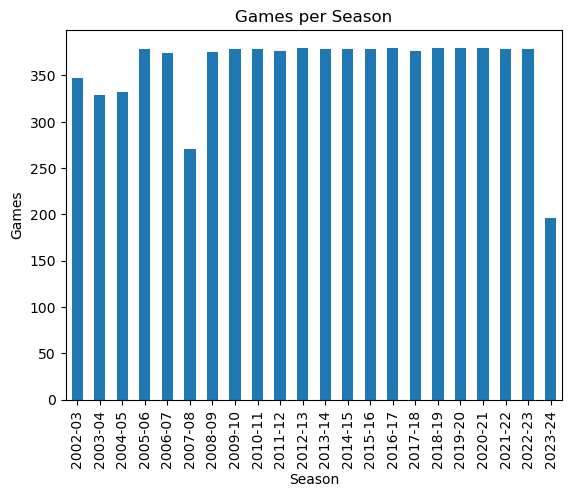

In [6]:
df.groupby('Season').size().plot(kind='bar')
plt.ylabel('Games')
plt.title('Games per Season')
plt.show()

In [7]:
print(f"Total rows: {df.shape[0]}")

print(df.groupby('Season').size())

print(f"Unique home teams: {df['HomeTeam'].nunique()}")
print(f"Unique away teams: {df['AwayTeam'].nunique()}")

Total rows: 7901
Season
2002-03    347
2003-04    329
2004-05    332
2005-06    378
2006-07    374
2007-08    271
2008-09    375
2009-10    378
2010-11    378
2011-12    376
2012-13    380
2013-14    378
2014-15    379
2015-16    378
2016-17    380
2017-18    376
2018-19    380
2019-20    380
2020-21    380
2021-22    378
2022-23    378
2023-24    196
dtype: int64
Unique home teams: 43
Unique away teams: 43


In [12]:
print((df.isnull().mean() * 100).round(2).sort_values(ascending=False))

B365<2.5                     67.1
B365>2.5                     67.1
FTHG                          0.0
HomeTeam_Wigan                0.0
AwayTeam_Cardiff              0.0
AwayTeam_Burnley              0.0
AwayTeam_Brighton             0.0
AwayTeam_Brentford            0.0
AwayTeam_Bournemouth          0.0
AwayTeam_Bolton               0.0
AwayTeam_Blackpool            0.0
AwayTeam_Blackburn            0.0
AwayTeam_Birmingham           0.0
AwayTeam_Aston Villa          0.0
AwayTeam_Arsenal              0.0
HomeTeam_Wolves               0.0
HomeTeam_West Ham             0.0
AwayTeam_Chelsea              0.0
HomeTeam_West Brom            0.0
HomeTeam_Watford              0.0
HomeTeam_Tottenham            0.0
HomeTeam_Swansea              0.0
HomeTeam_Sunderland           0.0
HomeTeam_Stoke                0.0
HomeTeam_Southampton          0.0
HomeTeam_Sheffield United     0.0
HomeTeam_Reading              0.0
HomeTeam_QPR                  0.0
HomeTeam_Portsmouth           0.0
HomeTeam_Nott'

In [15]:
print(df.isnull().sum())

FTHG                         0
FTAG                         0
FTR                          0
HTHG                         0
HTAG                         0
HTR                          0
Referee                      0
HS                           0
AS                           0
HST                          0
AST                          0
HC                           0
AC                           0
HF                           0
AF                           0
HY                           0
AY                           0
HR                           0
AR                           0
IWH                          0
IWD                          0
IWA                          0
WHH                          0
WHD                          0
WHA                          0
B365H                        0
B365D                        0
B365A                        0
B365>2.5                     0
B365<2.5                     0
Date                         0
Season                       0
Year    

In [14]:
for col in ['B365>2.5', 'B365<2.5']:
    df[col].fillna(df[col].mean(), inplace=True)

/var/folders/hh/pmnpfh4502s2v05fp58g729w0000gn/T/ipykernel_44532/3534365700.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [16]:
df.to_csv("premier_league_clean.csv", index=False)